## v1 — direct box regression (abandoned)

A ResNet-18 regressing normalised `(xmin, ymin, xmax, ymax)` under a GIoU loss.
The reasoning was sound -- the metric is IoU, so optimise IoU -- but the target
space is not: the network is asked for coordinates outside the image it is
looking at, with no anchor for their scale. Kept because the failure is the
reason the reparameterisation exists.

---

**Provenance.** This is an as-run artifact from the BrabantHack 2026 DEMCON
challenge, preserved with its original outputs so the numbers quoted in
[`docs/experiments.md`](../docs/experiments.md) can be checked against the logs
that produced them. Paths are relative to the original repository layout.

The method it arrived at has since been rewritten as a tested package under
[`src/shadow_detection/`](../src/shadow_detection); run
`shadow-detection train --help` rather than this notebook.


# BrabantHack 26 - Training Pipeline

ResNet18 regressor: image -> off-screen person bbox + walking direction.

Key data properties (from EDA):
- 720x480 images, 1692 train, 414 test
- Person always left or right of frame (852 left, 840 right)
- Y position nearly constant (ymin ~ 0.46, ymax ~ 0.84)
- X is the hard axis: xmin in [-0.50, 1.30]
- Direction nearly balanced (48.3% into frame)
- Baseline per-edge mean IoU: 0.4295 (floor to beat)

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/y2a/Hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA RTX A6000


In [2]:
# ---- Paths ----
TRAIN_DIR = Path("../data/train_data/train_data")
TEST_DIR = Path("../data/test_data/test_data")  # adjust if different
SAMPLE_CSV = Path("../data/sample_solution.csv")
CHECKPOINT_PATH = Path("best_model.pt")
SUBMISSION_PATH = Path("submission.csv")

# Verify
assert TRAIN_DIR.exists(), f"Train dir not found: {TRAIN_DIR}"
n_train_imgs = len(list(TRAIN_DIR.glob("*.png")))
n_test_imgs = len(list(TEST_DIR.glob("*.png"))) if TEST_DIR.exists() else 0
print(f"Train images: {n_train_imgs}")
print(f"Test images:  {n_test_imgs}")

Train images: 1692
Test images:  414


In [3]:
# ---- Hyperparameters ----
# Tuned for this specific dataset.

IMG_SIZE = 320          # 224 loses shadow detail at 720x480. 320 is a good
                        # balance: 2x downscale preserves shadow shape while
                        # keeping batch throughput fast.

BATCH_SIZE = 32         # 1692 samples / 32 = 53 batches per epoch. Fast enough
                        # for ~60 epochs in 15-20 min on a single GPU.

EPOCHS = 80             # Cosine schedule with warm restarts needs enough epochs
                        # to complete at least 2-3 cycles.

LR = 3e-4               # Higher than typical 1e-4 because the task is relatively
                        # simple (constrained output space) and we want fast
                        # convergence in a hackathon.

WEIGHT_DECAY = 1e-4     # Light regularization. Dataset is large enough (1692)
                        # that overfitting isn't the primary concern.

VAL_SPLIT = 0.12        # ~200 val images. Enough for stable IoU estimation
                        # while keeping most data for training.

BBOX_LOSS_W = 1.0       # GIoU loss weight
DIR_LOSS_W = 0.15       # Direction is only +/-0.05 in the competition metric.
                        # Keep this low so bbox gradients dominate.

BACKBONE = "resnet18"   # Fast, sufficient for this constrained problem.
SEED = 42

## 1. Dataset

In [4]:
class ShadowBBoxDataset(Dataset):
    """
    Loads shadow images and their off-screen person bbox annotations.

    JSON format (from EDA):
        bbox.top_left = [x, y]   (list, not dict)
        walking_into_frame_bool = 0 or 1

    Output bbox is normalized [xmin, ymin, xmax, ymax] where values
    outside [0,1] are expected (person is off-screen).

    Augmentation: horizontal flip with 50% probability during training.
    When flipping:
      - xmin_new = 1.0 - xmax_old, xmax_new = 1.0 - xmin_old
      - direction flips (person walking left->right becomes right->left)
    This is safe because left/right distribution is balanced (852 vs 840).
    """

    def __init__(
        self,
        data_dir: str | Path,
        img_size: int = 320,
        is_test: bool = False,
        augment: bool = False,
    ):
        self.data_dir = Path(data_dir)
        self.img_size = img_size
        self.is_test = is_test
        self.augment = augment

        self.image_paths = sorted(self.data_dir.glob("*.png"))
        if not self.image_paths:
            self.image_paths = sorted(self.data_dir.glob("*.jpg"))
        assert self.image_paths, f"No images found in {self.data_dir}"

        # Normalization: use actual dataset statistics from EDA.
        # Close to ImageNet but slightly different.
        self.normalize = transforms.Normalize(
            mean=[0.436, 0.433, 0.419],
            std=[0.161, 0.175, 0.239],
        )

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> dict:
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size  # 720, 480

        # Resize
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)

        # Decide flip before converting to tensor
        do_flip = self.augment and random.random() < 0.5
        if do_flip:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)

        # To tensor + normalize
        image_tensor = transforms.ToTensor()(image)  # [0, 1]
        image_tensor = self.normalize(image_tensor)

        result = {
            "image": image_tensor,
            "stem": img_path.stem,
            "orig_w": orig_w,
            "orig_h": orig_h,
        }

        if self.is_test:
            return result

        # Load annotation
        json_path = img_path.with_suffix(".json")
        with open(json_path) as f:
            ann = json.load(f)

        bbox = ann["bbox"]
        all_x = [bbox["top_left"][0], bbox["top_right"][0],
                 bbox["bottom_left"][0], bbox["bottom_right"][0]]
        all_y = [bbox["top_left"][1], bbox["top_right"][1],
                 bbox["bottom_left"][1], bbox["bottom_right"][1]]

        xmin = min(all_x) / orig_w
        ymin = min(all_y) / orig_h
        xmax = max(all_x) / orig_w
        ymax = max(all_y) / orig_h

        direction = float(ann["walking_into_frame_bool"])

        # Apply flip to bbox and direction
        if do_flip:
            xmin_new = 1.0 - xmax
            xmax_new = 1.0 - xmin
            xmin, xmax = xmin_new, xmax_new
            direction = 1.0 - direction  # flip walking direction

        result["bbox"] = torch.tensor([xmin, ymin, xmax, ymax], dtype=torch.float32)
        result["direction"] = torch.tensor(direction, dtype=torch.float32)
        return result

In [5]:
# Quick sanity check: load one sample, print shapes and values
ds_check = ShadowBBoxDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=False)
sample = ds_check[0]
print(f"Image tensor: {sample['image'].shape} dtype={sample['image'].dtype}")
print(f"Bbox: {sample['bbox'].numpy()}")
print(f"Direction: {sample['direction'].item()}")
print(f"Stem: {sample['stem']}")
print(f"Orig size: {sample['orig_w']}x{sample['orig_h']}")

# Verify bbox is reasonable
b = sample['bbox'].numpy()
print(f"\nBbox normalized: xmin={b[0]:.3f} ymin={b[1]:.3f} xmax={b[2]:.3f} ymax={b[3]:.3f}")
print(f"Bbox pixel: xmin={b[0]*720:.0f} ymin={b[1]*480:.0f} xmax={b[2]*720:.0f} ymax={b[3]*480:.0f}")

Image tensor: torch.Size([3, 320, 320]) dtype=torch.float32
Bbox: [-0.31788492  0.46587238 -0.15363178  0.8674141 ]
Direction: 1.0
Stem: image_0
Orig size: 720x480

Bbox normalized: xmin=-0.318 ymin=0.466 xmax=-0.154 ymax=0.867
Bbox pixel: xmin=-229 ymin=224 xmax=-111 ymax=416


## 2. Model

In [6]:
class ShadowPersonLocalizer(nn.Module):
    """
    Pretrained ResNet backbone -> shared neck -> two heads.

    bbox_head: 4 values [xmin, ymin, xmax, ymax] normalized.
               Linear output, NO sigmoid (coords can be <0 or >1).

    dir_head:  1 logit -> sigmoid at inference.
               Separate from bbox because direction and position are
               partially independent (a person on the left can walk
               either into or out of frame).
    """

    def __init__(self, backbone: str = "resnet18"):
        super().__init__()

        if backbone == "resnet18":
            base = models.resnet18(weights="IMAGENET1K_V1")
            feat_dim = 512
        elif backbone == "resnet34":
            base = models.resnet34(weights="IMAGENET1K_V1")
            feat_dim = 512
        else:
            raise ValueError(f"Unknown backbone: {backbone}")

        # Everything except the final FC layer
        self.features = nn.Sequential(*list(base.children())[:-1])

        self.neck = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )

        # Bbox head: 4 coords, linear output
        self.bbox_head = nn.Linear(128, 4)

        # Direction head: 1 logit
        self.dir_head = nn.Linear(128, 1)

        # Initialize bbox head bias to dataset mean bbox.
        # This gives the model a reasonable starting point instead of
        # random predictions that have zero IoU.
        # Mean bbox (from EDA, combining left and right):
        #   Since left/right cancel in X, use median instead: ~0.5
        #   Y is stable: ymin~0.46, ymax~0.84
        # Actually better to init to left-side mean since that's half
        # the data. The model will learn to adjust quickly.
        with torch.no_grad():
            # Neutral init: roughly centered, typical Y range
            self.bbox_head.bias.copy_(torch.tensor([0.0, 0.46, 0.15, 0.84]))

    def forward(self, x: torch.Tensor):
        feats = self.features(x)
        neck = self.neck(feats)
        bbox = self.bbox_head(neck)
        direction = self.dir_head(neck)
        return bbox, direction

In [7]:
# Quick check: forward pass
model_check = ShadowPersonLocalizer(BACKBONE)
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
bbox_out, dir_out = model_check(dummy)
print(f"Bbox output shape: {bbox_out.shape}")  # [2, 4]
print(f"Dir output shape:  {dir_out.shape}")   # [2, 1]
print(f"Initial bbox prediction: {bbox_out[0].detach().numpy()}")

n_params = sum(p.numel() for p in model_check.parameters())
n_trainable = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,} total, {n_trainable:,} trainable")
del model_check

Bbox output shape: torch.Size([2, 4])
Dir output shape:  torch.Size([2, 1])
Initial bbox prediction: [0.20224275 0.40777096 0.3138857  1.1031163 ]
Parameters: 11,341,381 total, 11,341,381 trainable


## 3. Loss: GIoU

Why GIoU instead of MSE/SmoothL1:
- Competition metric IS IoU. GIoU directly optimizes it.
- MSE can give low coordinate error but terrible IoU if the box is shifted.
- GIoU has gradient even when boxes don't overlap (unlike plain IoU), which
  matters early in training when predictions are random.

In [8]:
def compute_giou(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    Generalized IoU for two sets of [xmin, ymin, xmax, ymax] boxes.
    Returns per-pair GIoU values in [-1, 1]. Higher = better.
    """
    # Ensure valid boxes (model might predict xmin > xmax early on)
    p_x1 = torch.min(pred[:, 0], pred[:, 2])
    p_y1 = torch.min(pred[:, 1], pred[:, 3])
    p_x2 = torch.max(pred[:, 0], pred[:, 2])
    p_y2 = torch.max(pred[:, 1], pred[:, 3])

    t_x1 = torch.min(target[:, 0], target[:, 2])
    t_y1 = torch.min(target[:, 1], target[:, 3])
    t_x2 = torch.max(target[:, 0], target[:, 2])
    t_y2 = torch.max(target[:, 1], target[:, 3])

    # Intersection
    ix1 = torch.max(p_x1, t_x1)
    iy1 = torch.max(p_y1, t_y1)
    ix2 = torch.min(p_x2, t_x2)
    iy2 = torch.min(p_y2, t_y2)
    inter = torch.clamp(ix2 - ix1, min=0) * torch.clamp(iy2 - iy1, min=0)

    # Union
    p_area = (p_x2 - p_x1) * (p_y2 - p_y1)
    t_area = (t_x2 - t_x1) * (t_y2 - t_y1)
    union = p_area + t_area - inter + 1e-7

    iou = inter / union

    # Enclosing box
    ex1 = torch.min(p_x1, t_x1)
    ey1 = torch.min(p_y1, t_y1)
    ex2 = torch.max(p_x2, t_x2)
    ey2 = torch.max(p_y2, t_y2)
    enclose = (ex2 - ex1) * (ey2 - ey1) + 1e-7

    giou = iou - (enclose - union) / enclose
    return giou, iou


def combined_loss(bbox_pred, bbox_gt, dir_pred, dir_gt):
    """GIoU for bbox + BCE for direction. Returns total loss and metrics dict."""
    giou, iou = compute_giou(bbox_pred, bbox_gt)
    bbox_loss = (1.0 - giou).mean()

    dir_loss = nn.functional.binary_cross_entropy_with_logits(
        dir_pred.squeeze(-1), dir_gt,
    )

    total = BBOX_LOSS_W * bbox_loss + DIR_LOSS_W * dir_loss

    # Direction accuracy
    with torch.no_grad():
        dir_preds_binary = (torch.sigmoid(dir_pred.squeeze(-1)) > 0.5).float()
        dir_acc = (dir_preds_binary == dir_gt).float().mean().item()

    metrics = {
        "loss": total.item(),
        "bbox_loss": bbox_loss.item(),
        "dir_loss": dir_loss.item(),
        "mean_giou": giou.mean().item(),
        "mean_iou": iou.clamp(min=0).mean().item(),
        "dir_acc": dir_acc,
    }
    return total, metrics

## 4. Training

In [9]:
# ---- Datasets and loaders ----
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

full_dataset = ShadowBBoxDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=False)
n_total = len(full_dataset)
n_val = int(n_total * VAL_SPLIT)
n_train = n_total - n_val

train_indices, val_indices = random_split(
    range(n_total), [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

# Train dataset WITH augmentation, val WITHOUT
train_ds = ShadowBBoxDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=True)
val_ds = ShadowBBoxDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=False)

train_subset = torch.utils.data.Subset(train_ds, train_indices.indices)
val_subset = torch.utils.data.Subset(val_ds, val_indices.indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Train: {len(train_subset)}, Val: {len(val_subset)}")
print(f"Batches per epoch: {len(train_loader)}")

Train: 1489, Val: 203
Batches per epoch: 47


In [10]:
# ---- Model, optimizer, scheduler ----
model = ShadowPersonLocalizer(BACKBONE).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY,
)

# Cosine annealing with warm restarts.
# T_0=15 means first cycle is 15 epochs, then doubles.
# This gives the model multiple chances to escape local minima.
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-6,
)

print(f"Model on {DEVICE}")
print(f"Optimizer: AdamW lr={LR} wd={WEIGHT_DECAY}")
print(f"Scheduler: CosineWarmRestarts T_0=15 T_mult=2")

Model on cuda
Optimizer: AdamW lr=0.0003 wd=0.0001
Scheduler: CosineWarmRestarts T_0=15 T_mult=2


In [11]:
# ---- Training loop ----
history = {"train_loss": [], "val_loss": [],
           "train_iou": [], "val_iou": [],
           "train_dir_acc": [], "val_dir_acc": [],
           "lr": []}

best_val_iou = -1.0
best_epoch = -1

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    accum = {"loss": 0, "mean_iou": 0, "dir_acc": 0}
    n_batches = 0

    for batch in train_loader:
        images = batch["image"].to(DEVICE)
        bbox_gt = batch["bbox"].to(DEVICE)
        dir_gt = batch["direction"].to(DEVICE)

        bbox_pred, dir_pred = model(images)
        loss, metrics = combined_loss(bbox_pred, bbox_gt, dir_pred, dir_gt)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        for k in accum:
            accum[k] += metrics.get(k, 0)
        n_batches += 1

    scheduler.step()
    train_avg = {k: v / n_batches for k, v in accum.items()}

    # --- Validate ---
    model.eval()
    val_accum = {"loss": 0, "mean_iou": 0, "dir_acc": 0}
    val_n = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(DEVICE)
            bbox_gt = batch["bbox"].to(DEVICE)
            dir_gt = batch["direction"].to(DEVICE)

            bbox_pred, dir_pred = model(images)
            _, metrics = combined_loss(bbox_pred, bbox_gt, dir_pred, dir_gt)

            for k in val_accum:
                val_accum[k] += metrics.get(k, 0)
            val_n += 1

    val_avg = {k: v / max(1, val_n) for k, v in val_accum.items()}

    # Log
    history["train_loss"].append(train_avg["loss"])
    history["val_loss"].append(val_avg["loss"])
    history["train_iou"].append(train_avg["mean_iou"])
    history["val_iou"].append(val_avg["mean_iou"])
    history["train_dir_acc"].append(train_avg["dir_acc"])
    history["val_dir_acc"].append(val_avg["dir_acc"])
    history["lr"].append(optimizer.param_groups[0]["lr"])

    # Save best
    saved = ""
    if val_avg["mean_iou"] > best_val_iou:
        best_val_iou = val_avg["mean_iou"]
        best_epoch = epoch + 1
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "val_iou": best_val_iou,
            "img_size": IMG_SIZE,
            "backbone": BACKBONE,
        }, CHECKPOINT_PATH)
        saved = " *SAVED*"

    if (epoch + 1) % 5 == 0 or epoch == 0 or saved:
        print(
            f"Epoch {epoch+1:3d}/{EPOCHS} | "
            f"loss={train_avg['loss']:.4f}/{val_avg['loss']:.4f} | "
            f"IoU={train_avg['mean_iou']:.4f}/{val_avg['mean_iou']:.4f} | "
            f"dir={train_avg['dir_acc']:.2f}/{val_avg['dir_acc']:.2f} | "
            f"lr={optimizer.param_groups[0]['lr']:.1e}{saved}"
        )

print(f"\nBest val IoU: {best_val_iou:.4f} at epoch {best_epoch}")
print(f"Baseline per-edge mean IoU was 0.4295 -- we need to beat this.")

Epoch   1/80 | loss=1.1551/1.0836 | IoU=0.0156/0.0215 | dir=0.51/0.51 | lr=3.0e-04 *SAVED*
Epoch   2/80 | loss=1.0540/0.9815 | IoU=0.0678/0.1426 | dir=0.50/0.49 | lr=2.9e-04 *SAVED*
Epoch   3/80 | loss=0.9944/0.9483 | IoU=0.1385/0.1642 | dir=0.49/0.49 | lr=2.7e-04 *SAVED*
Epoch   4/80 | loss=0.9598/0.8950 | IoU=0.1717/0.2196 | dir=0.49/0.47 | lr=2.5e-04 *SAVED*
Epoch   5/80 | loss=0.9440/0.8799 | IoU=0.1856/0.2296 | dir=0.48/0.41 | lr=2.3e-04 *SAVED*
Epoch   6/80 | loss=0.9338/0.8629 | IoU=0.1887/0.2511 | dir=0.51/0.44 | lr=2.0e-04 *SAVED*
Epoch   7/80 | loss=0.9092/0.8459 | IoU=0.2146/0.2647 | dir=0.52/0.49 | lr=1.7e-04 *SAVED*
Epoch   9/80 | loss=0.9072/0.8305 | IoU=0.2120/0.2784 | dir=0.51/0.47 | lr=1.0e-04 *SAVED*
Epoch  10/80 | loss=0.8943/0.8344 | IoU=0.2236/0.2748 | dir=0.49/0.54 | lr=7.6e-05
Epoch  11/80 | loss=0.8746/0.8141 | IoU=0.2442/0.2933 | dir=0.49/0.46 | lr=5.0e-05 *SAVED*
Epoch  12/80 | loss=0.8854/0.8161 | IoU=0.2315/0.2938 | dir=0.51/0.46 | lr=3.0e-05 *SAVED*
Epoch  

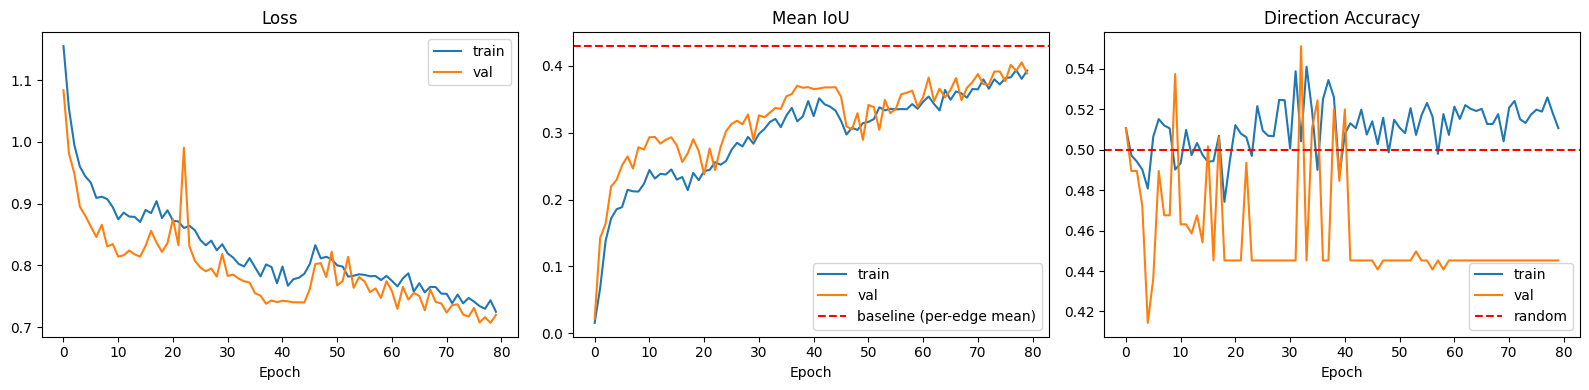

In [12]:
# ---- Training curves ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].set_xlabel("Epoch")

axes[1].plot(history["train_iou"], label="train")
axes[1].plot(history["val_iou"], label="val")
axes[1].axhline(0.4295, color="red", ls="--", label="baseline (per-edge mean)")
axes[1].set_title("Mean IoU")
axes[1].legend()
axes[1].set_xlabel("Epoch")

axes[2].plot(history["train_dir_acc"], label="train")
axes[2].plot(history["val_dir_acc"], label="val")
axes[2].axhline(0.5, color="red", ls="--", label="random")
axes[2].set_title("Direction Accuracy")
axes[2].legend()
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Validation analysis

In [13]:
# Load best model and run detailed val analysis
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded best model from epoch {ckpt['epoch']} (val IoU={ckpt['val_iou']:.4f})")

val_results = []
with torch.no_grad():
    for batch in val_loader:
        images = batch["image"].to(DEVICE)
        bbox_gt = batch["bbox"].cpu().numpy()
        dir_gt = batch["direction"].cpu().numpy()
        stems = batch["stem"]
        orig_w = batch["orig_w"].numpy()
        orig_h = batch["orig_h"].numpy()

        bbox_pred, dir_pred = model(images)
        bbox_pred = bbox_pred.cpu().numpy()
        dir_prob = torch.sigmoid(dir_pred).cpu().numpy().squeeze(-1)

        for i in range(len(stems)):
            # Compute IoU in normalized coords
            gt = bbox_gt[i]
            pr = bbox_pred[i]
            # Ensure valid boxes for IoU
            gt_valid = [min(gt[0], gt[2]), min(gt[1], gt[3]),
                        max(gt[0], gt[2]), max(gt[1], gt[3])]
            pr_valid = [min(pr[0], pr[2]), min(pr[1], pr[3]),
                        max(pr[0], pr[2]), max(pr[1], pr[3])]

            ix1 = max(gt_valid[0], pr_valid[0])
            iy1 = max(gt_valid[1], pr_valid[1])
            ix2 = min(gt_valid[2], pr_valid[2])
            iy2 = min(gt_valid[3], pr_valid[3])
            inter = max(0, ix2-ix1) * max(0, iy2-iy1)
            gt_a = (gt_valid[2]-gt_valid[0]) * (gt_valid[3]-gt_valid[1])
            pr_a = (pr_valid[2]-pr_valid[0]) * (pr_valid[3]-pr_valid[1])
            iou = inter / (gt_a + pr_a - inter + 1e-7)

            dir_correct = int((dir_prob[i] > 0.5) == dir_gt[i])

            val_results.append({
                "stem": stems[i],
                "iou": iou,
                "dir_correct": dir_correct,
                "gt_xmin": gt[0], "gt_ymin": gt[1],
                "gt_xmax": gt[2], "gt_ymax": gt[3],
                "pr_xmin": pr[0], "pr_ymin": pr[1],
                "pr_xmax": pr[2], "pr_ymax": pr[3],
                "gt_dir": dir_gt[i],
                "pr_dir_prob": dir_prob[i],
            })

val_df = pd.DataFrame(val_results)
print(f"\nValidation results ({len(val_df)} images):")
print(f"  Mean IoU:     {val_df['iou'].mean():.4f}")
print(f"  Median IoU:   {val_df['iou'].median():.4f}")
print(f"  IoU > 0.5:    {(val_df['iou'] > 0.5).mean()*100:.1f}%")
print(f"  IoU > 0.3:    {(val_df['iou'] > 0.3).mean()*100:.1f}%")
print(f"  IoU == 0:     {(val_df['iou'] < 0.01).mean()*100:.1f}%")
print(f"  Dir accuracy: {val_df['dir_correct'].mean()*100:.1f}%")
print(f"\n  Competition score estimate: {val_df['iou'].mean() + 0.05 * (2 * val_df['dir_correct'].mean() - 1):.4f}")

Loaded best model from epoch 79 (val IoU=0.4053)

Validation results (203 images):
  Mean IoU:     0.4046
  Median IoU:   0.3496
  IoU > 0.5:    40.4%
  IoU > 0.3:    52.2%
  IoU == 0:     0.0%
  Dir accuracy: 46.3%

  Competition score estimate: 0.4009


In [14]:
# Worst predictions
print("Worst 10 predictions (lowest IoU):")
worst = val_df.nsmallest(10, "iou")
display(worst[["stem", "iou", "dir_correct",
               "gt_xmin", "gt_xmax", "pr_xmin", "pr_xmax"]].round(3))

# Check if worst predictions are on a specific edge
print(f"\nWorst predictions - predicted side vs GT side:")
for _, row in worst.iterrows():
    gt_side = "left" if row["gt_xmax"] < 0.5 else "right"
    pr_side = "left" if row["pr_xmax"] < 0.5 else "right"
    print(f"  {row['stem']}: GT={gt_side} pred={pr_side} IoU={row['iou']:.3f}")

Worst 10 predictions (lowest IoU):


,stem,iou,dir_correct,gt_xmin,gt_xmax,pr_xmin,pr_xmax
54,image_848,0.048,1,1.279,1.344,1.304,0.824
167,image_2984,0.054,1,1.152,1.191,1.320,0.762
11,image_1587,0.054,1,1.170,1.320,1.204,0.752
66,image_254,0.063,1,1.213,1.308,1.248,0.761
46,image_159,0.068,1,1.177,1.220,1.286,0.745
114,image_598,0.074,1,1.160,1.209,1.329,0.768
25,image_1967,0.075,0,1.130,1.181,1.385,0.792
143,image_1026,0.077,1,1.158,1.213,1.353,0.779
29,image_1355,0.078,0,1.122,1.176,1.320,0.762
153,image_1109,0.079,0,1.146,1.198,1.303,0.751



Worst predictions - predicted side vs GT side:
  image_848: GT=right pred=right IoU=0.048
  image_2984: GT=right pred=right IoU=0.054
  image_1587: GT=right pred=right IoU=0.054
  image_254: GT=right pred=right IoU=0.063
  image_159: GT=right pred=right IoU=0.068
  image_598: GT=right pred=right IoU=0.074
  image_1967: GT=right pred=right IoU=0.075
  image_1026: GT=right pred=right IoU=0.077
  image_1355: GT=right pred=right IoU=0.078
  image_1109: GT=right pred=right IoU=0.079


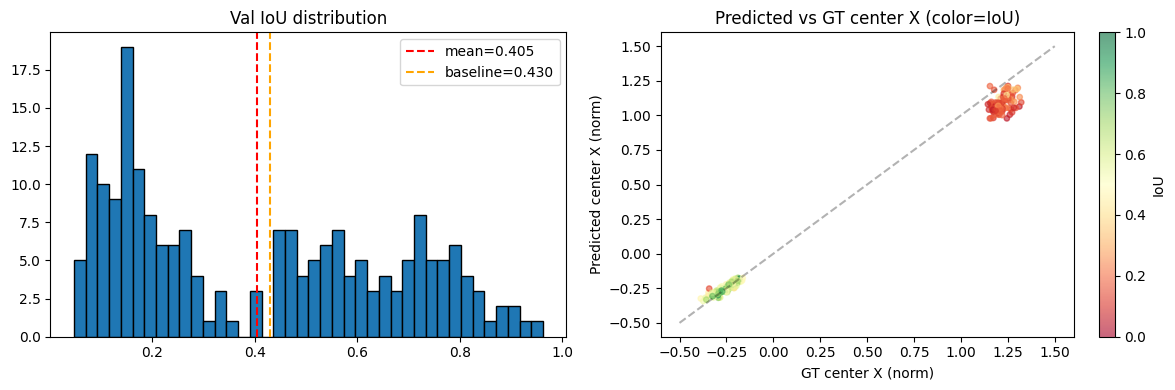

In [15]:
# IoU distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(val_df["iou"], bins=40, edgecolor="black")
axes[0].axvline(val_df["iou"].mean(), color="red", ls="--",
               label=f"mean={val_df['iou'].mean():.3f}")
axes[0].axvline(0.4295, color="orange", ls="--", label="baseline=0.430")
axes[0].set_title("Val IoU distribution")
axes[0].legend()

# Scatter: predicted vs GT center X
gt_cx = (val_df["gt_xmin"] + val_df["gt_xmax"]) / 2
pr_cx = (val_df["pr_xmin"] + val_df["pr_xmax"]) / 2
axes[1].scatter(gt_cx, pr_cx, c=val_df["iou"], cmap="RdYlGn",
               alpha=0.6, s=15, vmin=0, vmax=1)
axes[1].plot([-0.5, 1.5], [-0.5, 1.5], "k--", alpha=0.3)
axes[1].set_xlabel("GT center X (norm)")
axes[1].set_ylabel("Predicted center X (norm)")
axes[1].set_title("Predicted vs GT center X (color=IoU)")
plt.colorbar(axes[1].collections[0], ax=axes[1], label="IoU")

plt.tight_layout()
plt.savefig("val_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Generate submission

In [16]:
# Load best model
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

test_ds = ShadowBBoxDataset(TEST_DIR, img_size=IMG_SIZE, is_test=True, augment=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)

print(f"Test set: {len(test_ds)} images")

predictions = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        images = batch["image"].to(DEVICE)
        orig_w = batch["orig_w"].float()
        orig_h = batch["orig_h"].float()
        stems = batch["stem"]

        bbox_pred, dir_pred = model(images)
        bbox_pred = bbox_pred.cpu()
        dir_prob = torch.sigmoid(dir_pred.cpu().squeeze(-1))

        for i in range(len(stems)):
            w = orig_w[i].item()
            h = orig_h[i].item()
            predictions.append({
                "stem": stems[i],
                "xmin": bbox_pred[i, 0].item() * w,
                "ymin": bbox_pred[i, 1].item() * h,
                "xmax": bbox_pred[i, 2].item() * w,
                "ymax": bbox_pred[i, 3].item() * h,
                "direction": 1 if dir_prob[i].item() > 0.5 else 0,
            })

pred_df = pd.DataFrame(predictions)
# Sort by image index
pred_df["_idx"] = pred_df["stem"].str.replace("image_", "").astype(int)
pred_df = pred_df.sort_values("_idx").drop(columns="_idx")

print(f"\nPrediction stats:")
print(f"  xmin: [{pred_df['xmin'].min():.1f}, {pred_df['xmin'].max():.1f}]")
print(f"  xmax: [{pred_df['xmax'].min():.1f}, {pred_df['xmax'].max():.1f}]")
print(f"  direction: {pred_df['direction'].value_counts().to_dict()}")
pred_df.head()

Test set: 414 images


Predicting: 100%|██████████| 7/7 [00:03<00:00,  2.20it/s]


Prediction stats:
  xmin: [-179.7, 1116.2]
  xmax: [-302.4, 726.8]
  direction: {1: 228, 0: 186}


,stem,xmin,ymin,xmax,ymax,direction
0,image_1,942.272730,222.195511,562.188263,401.467066,0
330,image_6,968.094893,221.784611,582.276163,404.702597,0
370,image_8,910.185957,223.185496,526.338158,392.849092,0
292,image_36,-105.269430,225.722866,-175.001993,365.394430,1
296,image_38,-132.511007,219.817128,-237.572329,428.767805,1


In [17]:
# Check submission format against sample_solution.csv
if SAMPLE_CSV.exists():
    sample = pd.read_csv(SAMPLE_CSV)
    print(f"Sample solution columns: {list(sample.columns)}")
    print(f"Sample solution rows: {len(sample)}")
    print(f"Our predictions rows: {len(pred_df)}")

    if len(sample) != len(pred_df):
        print(f"WARNING: row count mismatch!")

    # Check if sample has an index column
    print(f"\nSample first 3 rows:")
    display(sample.head(3))

In [18]:
# Save submission
# Match the exact format of sample_solution.csv
submission = pred_df[["xmin", "ymin", "xmax", "ymax", "direction"]].copy()

# If sample_solution has an index column like 'image_0', add it
if SAMPLE_CSV.exists():
    sample = pd.read_csv(SAMPLE_CSV)
    # Check if there's a string index
    if sample.columns[0] not in ["xmin", "ymin", "xmax", "ymax", "direction"]:
        # First column is an ID column
        id_col = sample.columns[0]
        submission.index = pred_df["stem"]
        submission.index.name = id_col
        print(f"Using index column: {id_col}")

submission.to_csv(SUBMISSION_PATH)
print(f"\nSubmission saved: {SUBMISSION_PATH}")
print(f"Shape: {submission.shape}")
print(f"\nFirst 5 rows:")
display(submission.head())

# Final verification
reload = pd.read_csv(SUBMISSION_PATH)
print(f"\nReloaded shape: {reload.shape}")
print(f"Columns: {list(reload.columns)}")
print(f"Direction values: {reload['direction'].unique()}")


Submission saved: submission.csv
Shape: (414, 5)

First 5 rows:


,xmin,ymin,xmax,ymax,direction
0,942.272730,222.195511,562.188263,401.467066,0
330,968.094893,221.784611,582.276163,404.702597,0
370,910.185957,223.185496,526.338158,392.849092,0
292,-105.269430,225.722866,-175.001993,365.394430,1
296,-132.511007,219.817128,-237.572329,428.767805,1



Reloaded shape: (414, 6)
Columns: ['Unnamed: 0', 'xmin', 'ymin', 'xmax', 'ymax', 'direction']
Direction values: [0 1]


## 7. Quick visual check on test predictions

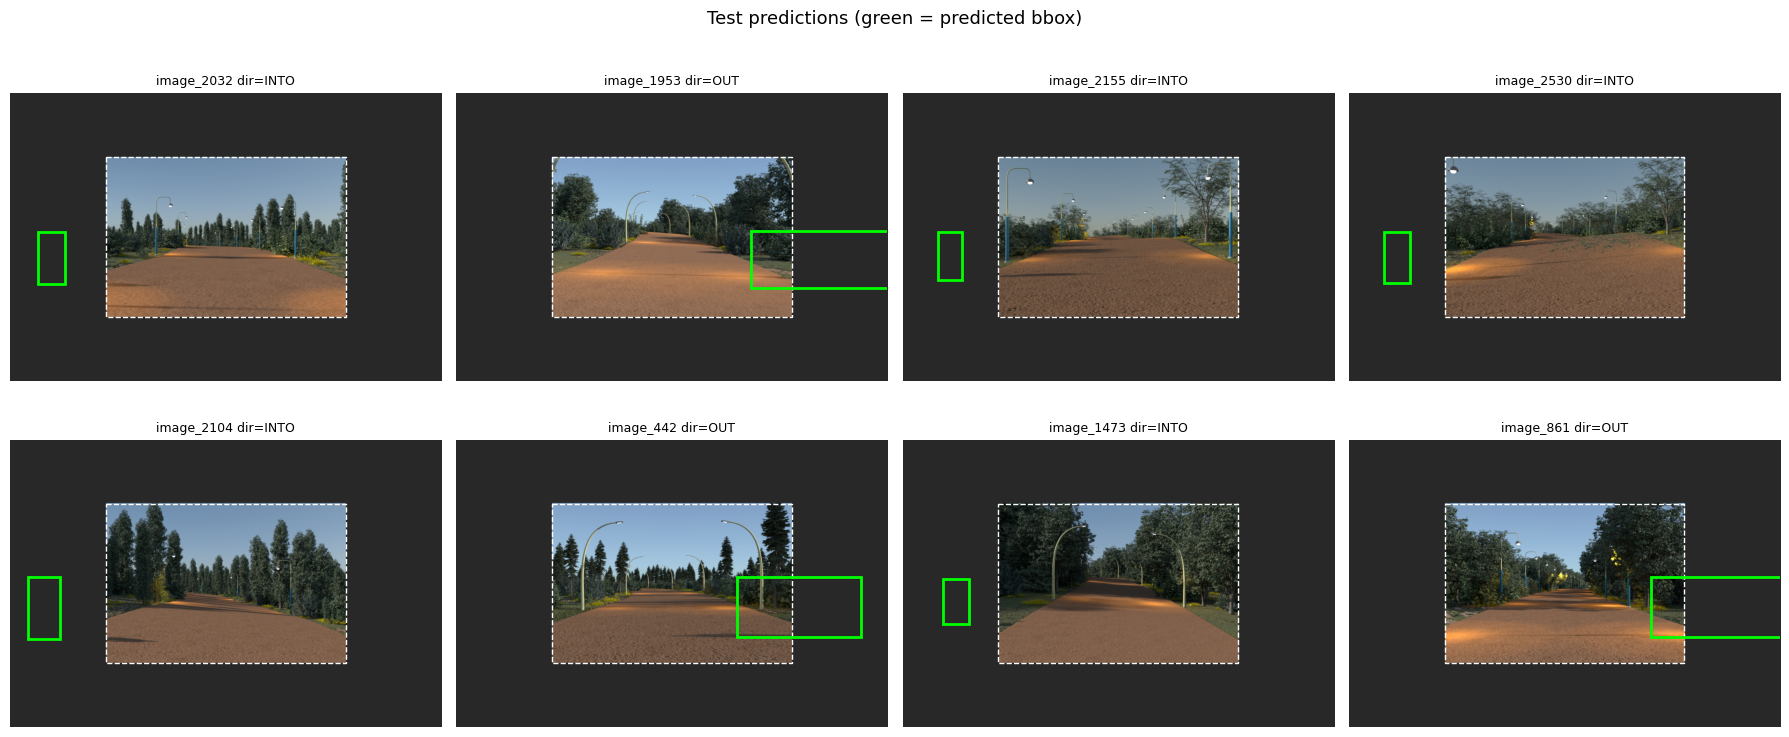

In [19]:
import matplotlib.patches as mpatches

def show_prediction(stem, pred_row, ax, data_dir, pad_ratio=0.4):
    img_path = data_dir / f"{stem}.png"
    img = np.asarray(Image.open(img_path).convert("RGB"))
    h, w = img.shape[:2]
    pad_x = int(w * pad_ratio)
    pad_y = int(h * pad_ratio)

    canvas = np.full((h + 2*pad_y, w + 2*pad_x, 3), 40, dtype=np.uint8)
    canvas[pad_y:pad_y+h, pad_x:pad_x+w] = img

    ax.imshow(canvas)

    # Frame
    frame = mpatches.Rectangle((pad_x, pad_y), w, h,
                               lw=1, ec="white", fc="none", ls="--")
    ax.add_patch(frame)

    # Predicted bbox
    bx = pred_row["xmin"] + pad_x
    by = pred_row["ymin"] + pad_y
    bw = pred_row["xmax"] - pred_row["xmin"]
    bh = pred_row["ymax"] - pred_row["ymin"]
    rect = mpatches.Rectangle((bx, by), bw, bh, lw=2, ec="lime", fc="none")
    ax.add_patch(rect)

    d = "INTO" if pred_row["direction"] == 1 else "OUT"
    ax.set_title(f"{stem} dir={d}", fontsize=9)
    ax.axis("off")


n_show = min(8, len(pred_df))
show_df = pred_df.sample(n=n_show, random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, (_, row) in enumerate(show_df.iterrows()):
    show_prediction(row["stem"], row, axes.flatten()[i], TEST_DIR)
for i in range(n_show, 8):
    axes.flatten()[i].axis("off")
plt.suptitle("Test predictions (green = predicted bbox)", fontsize=13)
plt.tight_layout()
plt.savefig("test_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Summary

After running this notebook:
1. `best_model.pt` -- trained checkpoint
2. `submission.csv` -- competition submission file
3. `training_curves.png` -- loss/IoU/accuracy over epochs
4. `val_analysis.png` -- IoU distribution and predicted vs GT scatter
5. `test_predictions.png` -- visual sanity check on test images

If val IoU is below 0.5, try:
- Increase EPOCHS to 120
- Try BACKBONE = "resnet34"
- Lower LR to 1e-4
- Add color jitter augmentation

If val IoU is above 0.6 but test score is lower:
- Overfitting. Increase WEIGHT_DECAY to 5e-4
- Increase VAL_SPLIT to 0.2 to check
- Add test-time augmentation (average original + flipped)

In [20]:
print("=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)
print(f"Best val IoU:      {best_val_iou:.4f}")
print(f"Best epoch:        {best_epoch}")
print(f"Baseline (edge):   0.4295")
print(f"Improvement:       {best_val_iou - 0.4295:+.4f}")
print(f"Val dir accuracy:  {val_df['dir_correct'].mean()*100:.1f}%")
print(f"Submission file:   {SUBMISSION_PATH}")
print(f"Submission rows:   {len(pred_df)}")

RESULTS SUMMARY
Best val IoU:      0.4053
Best epoch:        79
Baseline (edge):   0.4295
Improvement:       -0.0242
Val dir accuracy:  46.3%
Submission file:   submission.csv
Submission rows:   414
